In [1]:
# A bunch of plotting stuff for our paper. We're gonna do this separately to make plotting easier after we've done all the data processing
import pandas as pd
import numpy as np

import plotly.express as px
from plotly import graph_objects as go

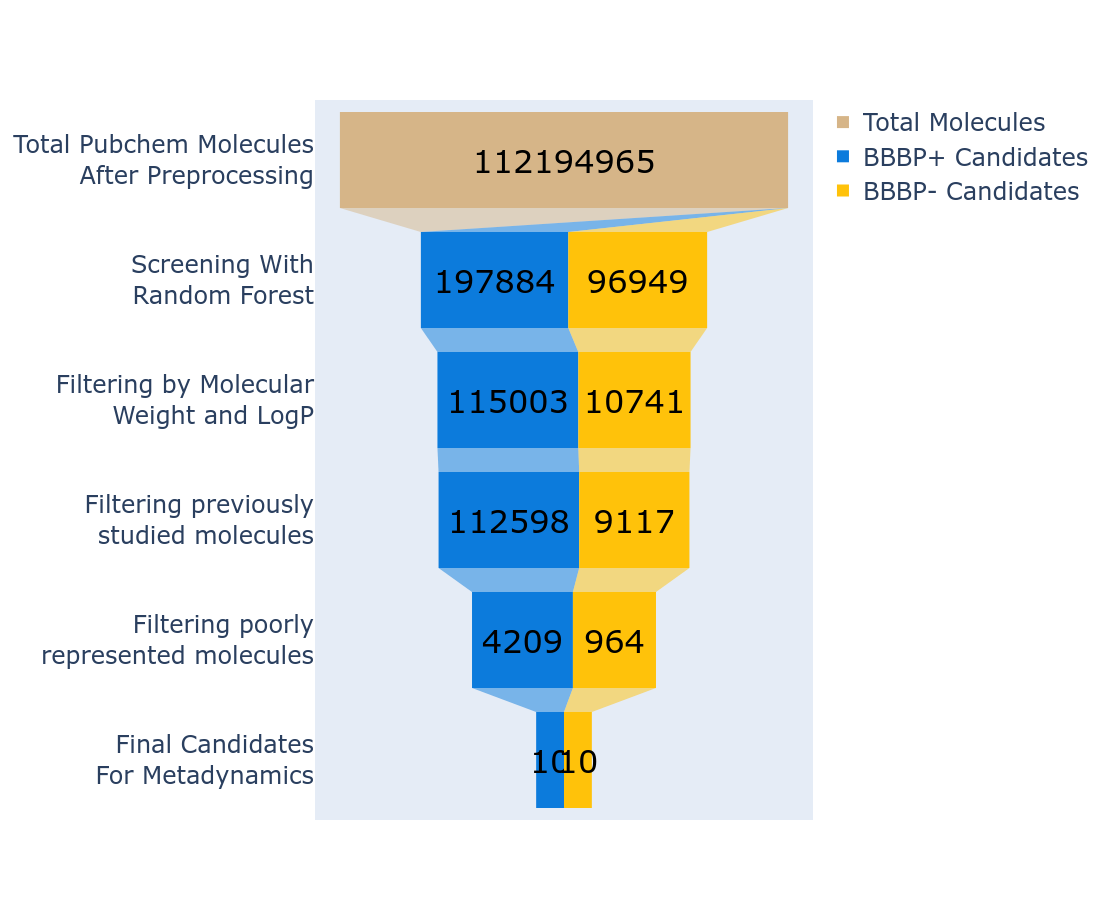

In [2]:
# Do the funnel plot
stages = [
    'Total Pubchem Molecules<br> After Preprocessing',
    'Screening With<br> Random Forest',
    'Filtering by Molecular<br> Weight and LogP',
    'Filtering previously<br> studied molecules',
    'Filtering poorly<br> represented molecules',
    'Final Candidates<br> For Metadynamics'
]

fig = go.Figure()


fig.add_trace(go.Funnel(
    name = 'Total Molecules',
    y = stages,
    x = [np.log10(112194965)*2, 0, 0, 0, 0], # Multiply by 2 to keep consistent with the scale of the rest of the plot
    text = [112194965, None, None, None],
    textposition="inside",
    textinfo="text",
    constraintext='outside',
    marker={"color": "#D6B588"},
    textfont=dict(
        size=32,
        color="black"
    ),
))

fig.add_trace(go.Funnel(
    name = 'BBBP+ Candidates',
    y = stages,
    x = np.log10([1, 197884, 115003, 112598, 4209, 10]),
    text = [None, 197884, 115003, 112598, 4209, 10],
    textposition="inside",
    textinfo="text",
    constraintext='outside',
    marker={"color": "#0C7BDC"},
    textfont=dict(
        size=32,
        color="black"
    ),
))

fig.add_trace(go.Funnel(
    name = 'BBBP- Candidates',
    y = stages,
    x = np.log10([1, 96949, 10741, 9117, 964, 10]),
    text = [None, 96949, 10741, 9117, 964, 10],
    textposition="inside",
    textinfo="text",
    constraintext='outside',
    marker={"color": "#FFC20A"},
    textfont=dict(
        size=32,
        color="black"
    ),
))

fig.update_layout(
    #xaxis_type="log", # Do this manually or things get real fucky
    #title=dict(text="Candidate Molecules Funnel Plot (Logarithmic Scale)", automargin=True),
    xaxis_title="Number of Candidates",
    font=dict(
        #family="Courier New, monospace",
        size=24,
        #color="RebeccaPurple"
    ),
    width=1600,
    height=900,
)

fig.write_image(
    "funnel_pubchem.png",
    width=1600,
    height=900,
)
fig.show()